In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Added for KDE plots

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

PROCESSED_DIR = os.path.join(project_root, 'results', 'processed')
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 120
print(f"Loading from {PROCESSED_DIR}")

MODELS = ["OffLattice", "Lattice", "Hybrid"]
SIZES = ["1M", "10M"]

datasets = []
for model in MODELS:
    for size in SIZES:
        base = f"{model}_{size}"
        scalars_path = os.path.join(PROCESSED_DIR, f"{base}_scalars.csv")
        
        if not os.path.isfile(scalars_path):
            print(f"Skipping {base}: scalars.csv not found.")
            continue
            
        df_scalars = pd.read_csv(scalars_path)
            
        datasets.append({
            "name": f"{model} ({size})", 
            "model": model, 
            "size": size,
            "df_scalars": df_scalars
        })
print(f"Loaded {len(datasets)} dataset(s).")

Loading from /Users/ramsaydavis/dla/results/processed
Loaded 6 dataset(s).


In [40]:
def plot_distributions(datasets, plot_specs, title="Distribution Comparison",ax=None,kde_on=True):
    """
    Plots KDE and histogram distributions for arbitrary combinations of model, size, and metric.
    
    Parameters:
    - datasets: The loaded list of dataset dictionaries.
    - plot_specs: A list of tuples defining what to plot. 
                  Format: [(model, size, metric), (model, size, metric), ...]
                  Example: [('Lattice', '1M', 'D_growth'), ('Lattice', '10M', 'D_growth')]
    """
    if ax is None:
        fig, current_ax = plt.subplots(figsize=(10, 6))
        standalone = True
    else:
        current_ax = ax
        standalone = False

    colors = sns.color_palette("muted", len(plot_specs))
    plt.sca(current_ax)
    
    for i, (model, size, metric) in enumerate(plot_specs):
        # Fetch the specific dataset from memory
        ds = next((d for d in datasets if d['model'] == model and d['size'] == size), None)
        if ds is None:
            print(f"Warning: Data for {model} {size} not found. Skipping.")
            continue
            
        df = ds['df_scalars']
        
        # Isolate the final snapshot size for this specific dataset
        max_n = df['snapshot_N'].max()
        df_final = df[df['snapshot_N'] == max_n].copy()
        
        # Calculate or extract the requested metric
        if metric == 'D_growth':
            data = 1.0 / df_final['beta']
            metric_label = "$D_{1/\\beta}$"
        elif metric == 'D':
            data = df_final['D']
            metric_label = "$D_{box}$"
        else:
            data = df_final[metric]
            metric_label = metric
            
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        
        label_str = f"{model} {size} {metric_label} (Mean: {data.mean():.3f})"
        
        # Plot the distribution
        sns.histplot(data, kde=kde_on, label=label_str, 
                     color=colors[i], stat="density", alpha=0.4, 
                     #bins=20
                     )

    # Reference Line
    #plt.axvline(1.71, color='k', linestyle='--', alpha=0.6, label='Theory (1.71)')
    
    plt.title(title)
    plt.xlabel("Fractal Dimension Value")
    plt.ylabel("Density")
    plt.legend(loc='upper right', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    if standalone:
        plt.tight_layout()
        plt.show()

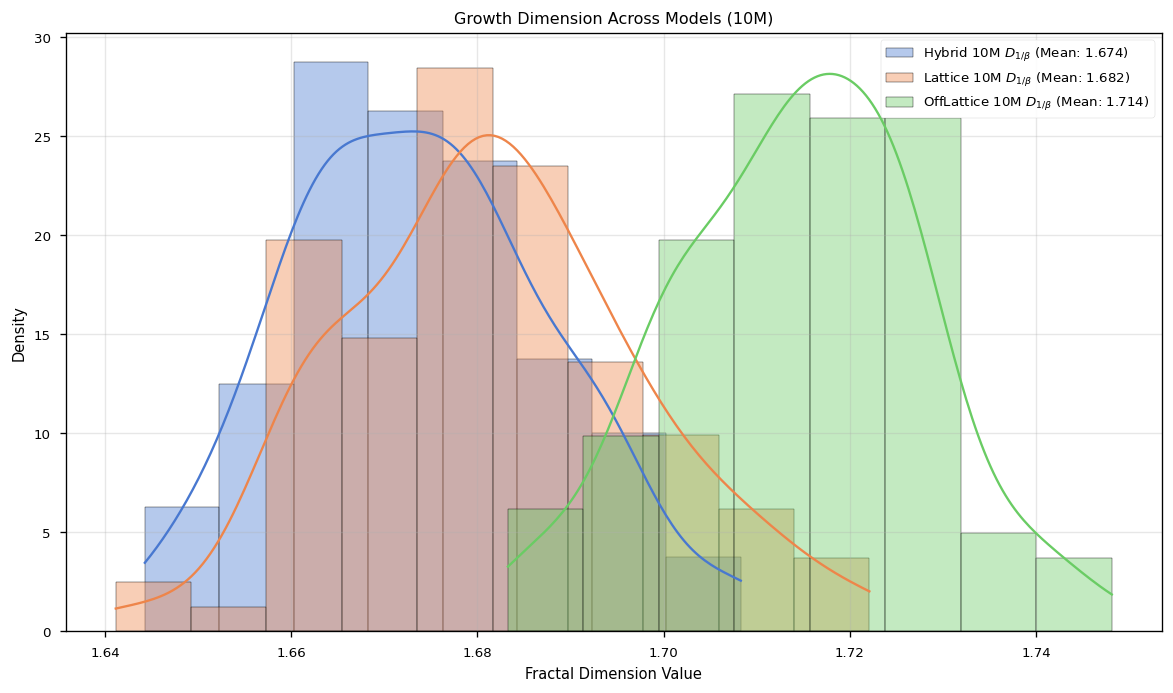

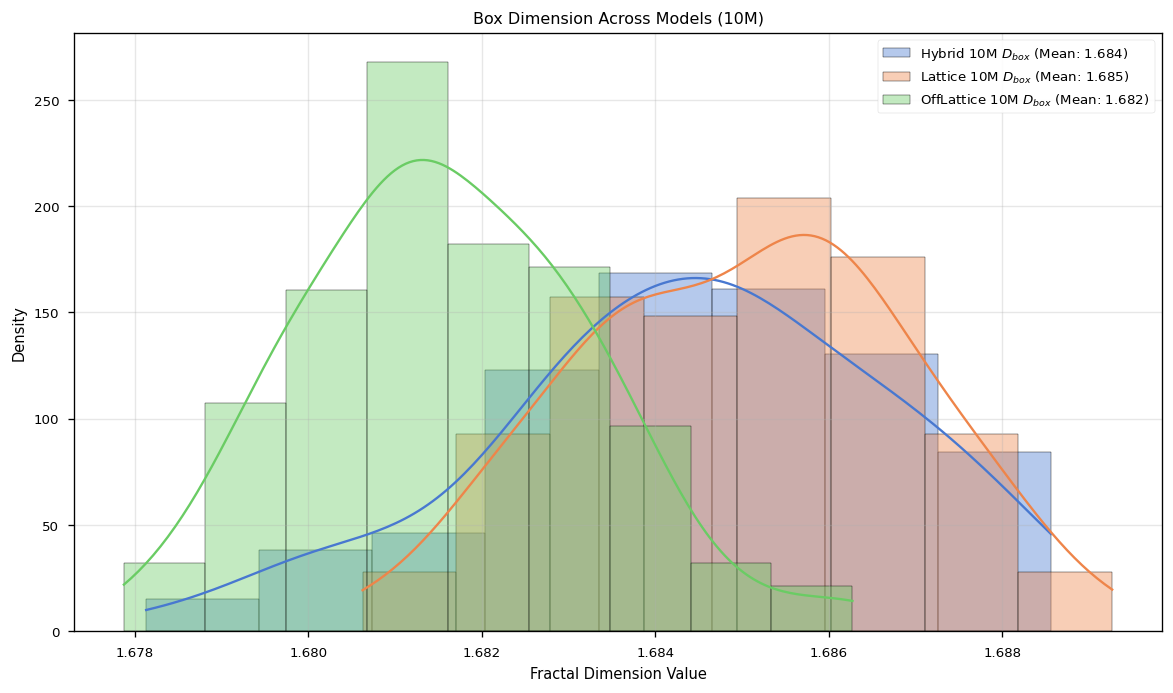

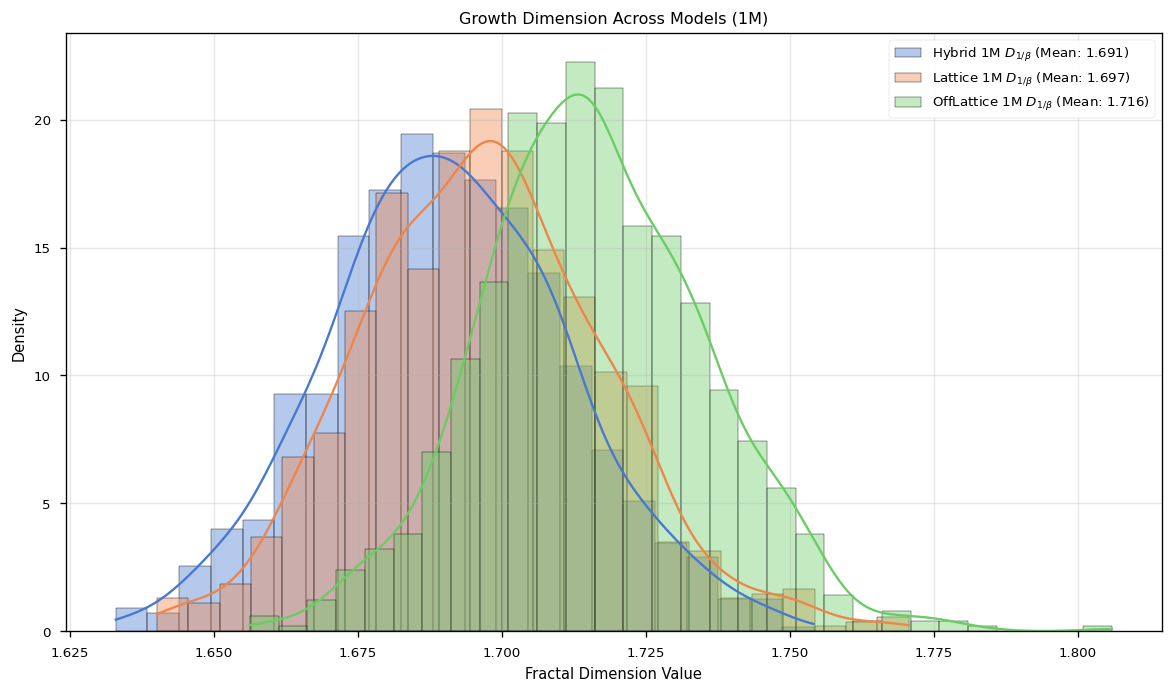

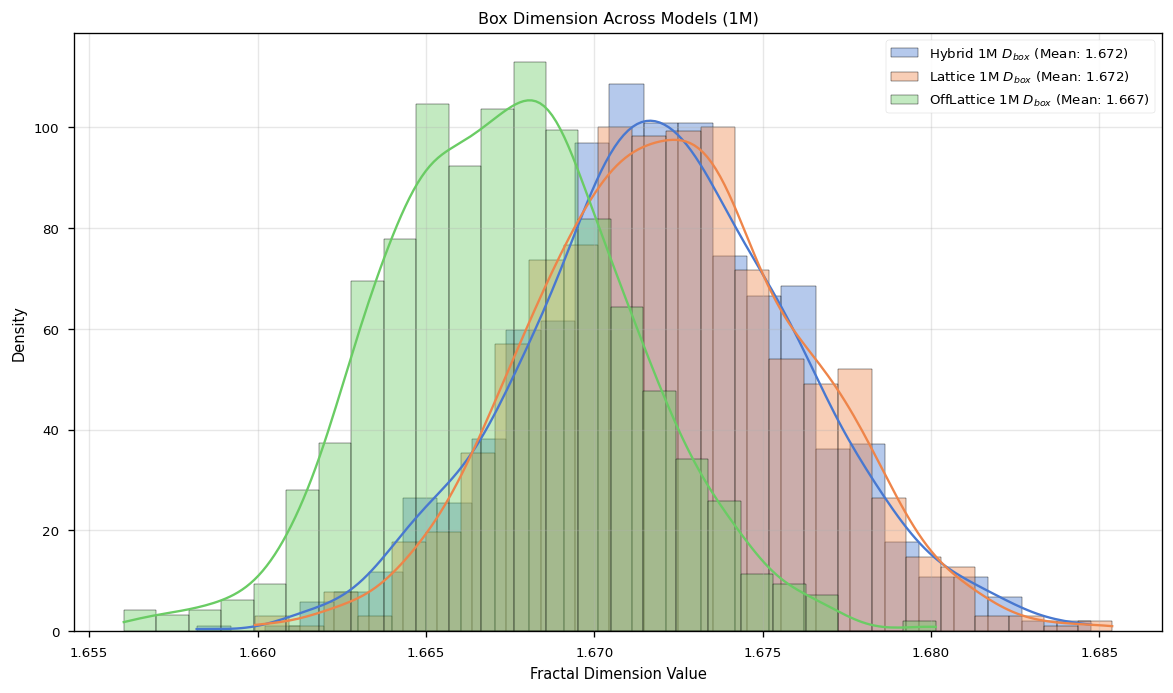

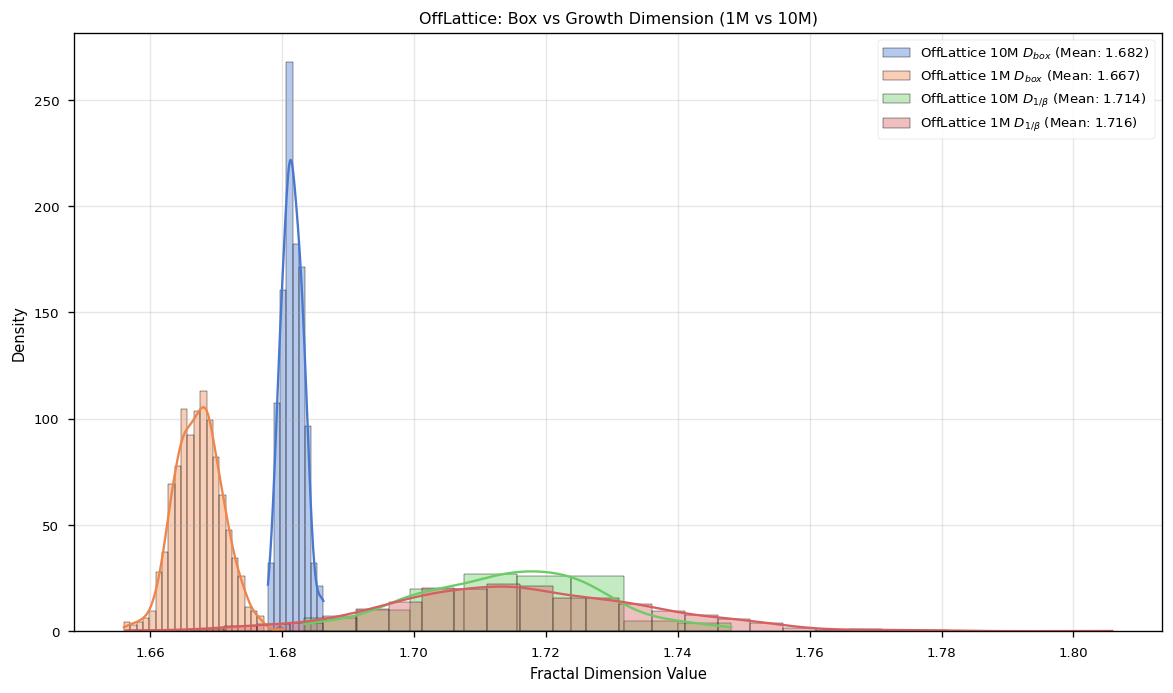

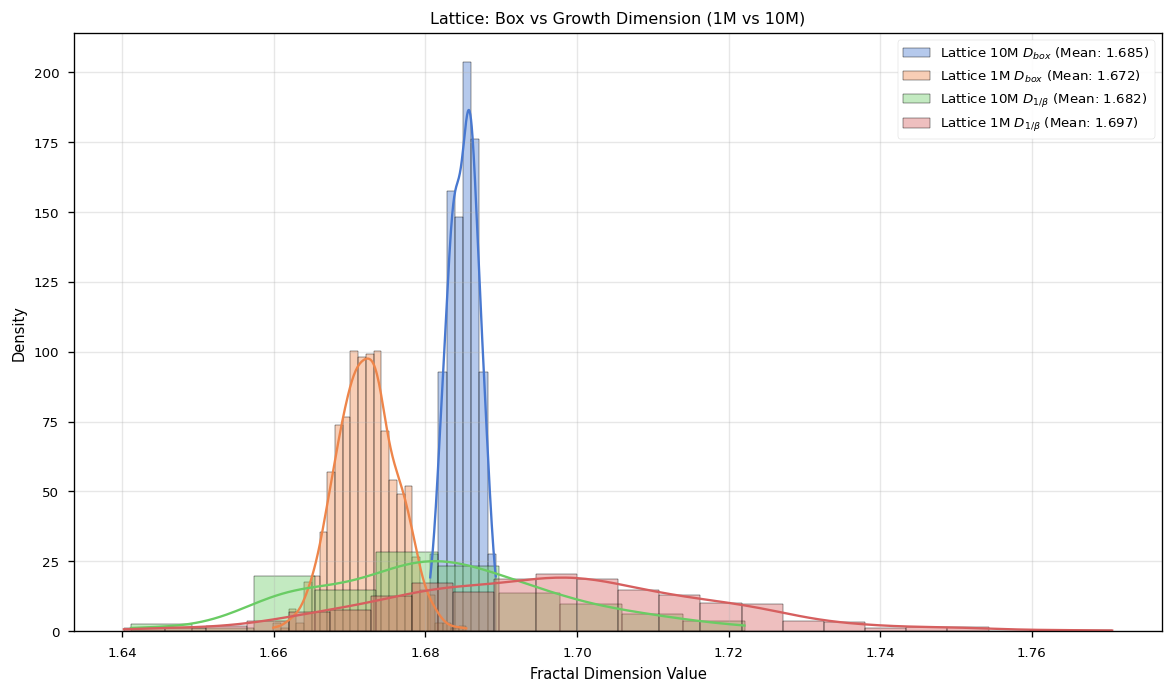

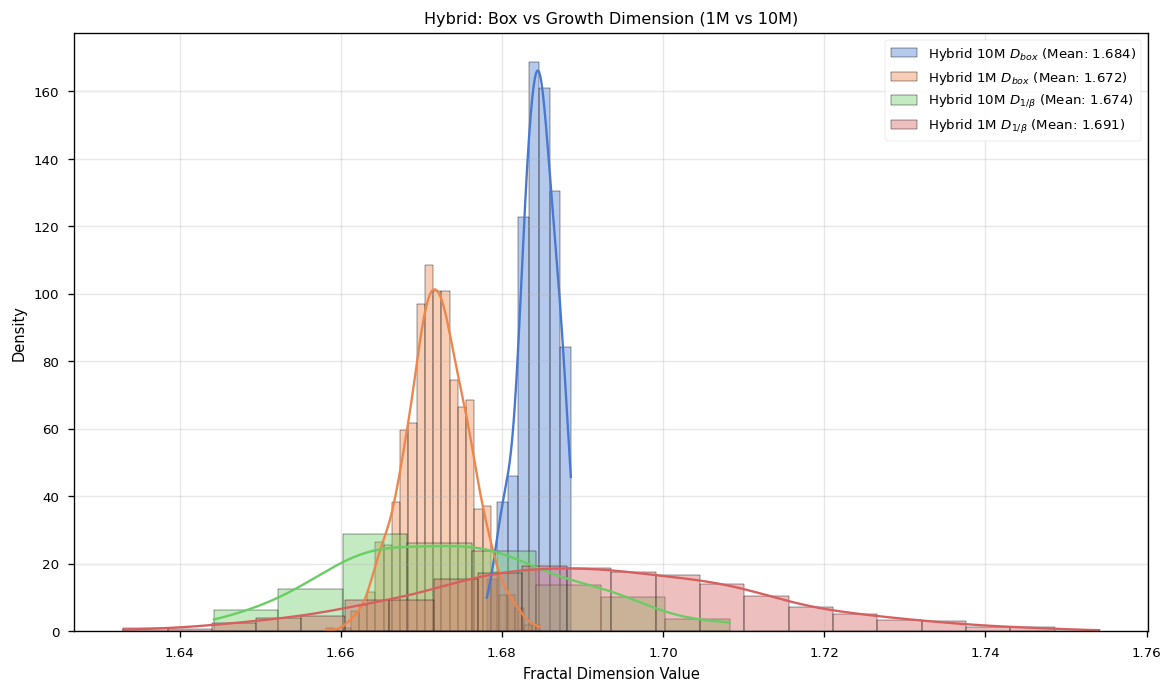

In [36]:
# Watch the Growth Dimension drop as the Lattice cluster grows from 1M to 10M
specs1 = [
    ('Hybrid', '10M', 'D_growth'),
    ('Lattice', '10M', 'D_growth'),
    ('OffLattice', '10M', 'D_growth')
]
plot_distributions(datasets, specs1, title="Growth Dimension Across Models (10M)")

specs2 = [
    ('Hybrid', '10M', 'D'),
    ('Lattice', '10M', 'D'),
    ('OffLattice', '10M', 'D')
]
plot_distributions(datasets, specs2, title="Box Dimension Across Models (10M)")

specs3 = [
    ('Hybrid', '1M', 'D_growth'),
    ('Lattice', '1M', 'D_growth'),
    ('OffLattice', '1M', 'D_growth')
]
plot_distributions(datasets, specs3, title="Growth Dimension Across Models (1M)")

specs4 = [
    ('Hybrid', '1M', 'D'),
    ('Lattice', '1M', 'D'),
    ('OffLattice', '1M', 'D')
]
plot_distributions(datasets, specs4, title="Box Dimension Across Models (1M)")

specs5 = [
    ('OffLattice', '10M', 'D'),
    ('OffLattice', '1M', 'D'),
    ('OffLattice', '10M', 'D_growth'),
    ('OffLattice', '1M', 'D_growth')
]
plot_distributions(datasets, specs5, title="OffLattice: Box vs Growth Dimension (1M vs 10M)")

specs6 = [
    ('Lattice', '10M', 'D'),
    ('Lattice', '1M', 'D'),
    ('Lattice', '10M', 'D_growth'),
    ('Lattice', '1M', 'D_growth')
]
plot_distributions(datasets, specs6, title="Lattice: Box vs Growth Dimension (1M vs 10M)")

specs7 = [
    ('Hybrid', '10M', 'D'),
    ('Hybrid', '1M', 'D'),
    ('Hybrid', '10M', 'D_growth'),
    ('Hybrid', '1M', 'D_growth')
]
plot_distributions(datasets, specs7, title="Hybrid: Box vs Growth Dimension (1M vs 10M)")


In [44]:
def plot_batch_dimension_evolution(datasets, model_name="Lattice", size_label="10M", ax=None):
    """
    Plots the statistical evolution of D_box and D_growth across the ensemble.
    Uses 5th/95th percentiles for the faint outer envelope and standard deviation for the inner envelope.
    """
    # If no axis is provided, create a new standalone figure
    if ax is None:
        fig, current_ax = plt.subplots(figsize=(10, 6))
        standalone = True
    else:
        current_ax = ax
        standalone = False
        
    # Explicitly set the active axis so Matplotlib targets the correct subplot
    plt.sca(current_ax)

    ds = next((d for d in datasets if d['model'] == model_name and d['size'] == size_label), None)
    if ds is None:
        print(f"Dataset {model_name}_{size_label} not found.")
        return

    df = ds['df_scalars'].copy()
    
    # Calculate Growth Dimension safely
    df['beta'] = pd.to_numeric(df['beta'], errors='coerce')
    df = df[df['beta'] > 0] 
    df['D_growth'] = 1.0 / df['beta']
    
    # Aggregate statistics per snapshot using 5th and 95th quantiles!
    stats = df.groupby('snapshot_N').agg(
        D_box_mean=('D', 'mean'), 
        D_box_std=('D', 'std'),
        D_box_min=('D', lambda x: x.quantile(0.05)), 
        D_box_max=('D', lambda x: x.quantile(0.95)),
        
        D_growth_mean=('D_growth', 'mean'), 
        D_growth_std=('D_growth', 'std'),
        D_growth_min=('D_growth', lambda x: x.quantile(0.05)), 
        D_growth_max=('D_growth', lambda x: x.quantile(0.95))
    ).dropna()

    n_vals = stats.index
    
    # --- 1. Plot Growth Dimension Evolution (Red) ---
    # Faint background shading for 5th-95th Percentile Range
    current_ax.fill_between(n_vals, stats['D_growth_min'], stats['D_growth_max'], 
                     color='tab:red', alpha=0.05, label='Growth 5-95% Range')
    # Darker shading for Standard Deviation
    current_ax.fill_between(n_vals, stats['D_growth_mean'] - stats['D_growth_std'], 
                     stats['D_growth_mean'] + stats['D_growth_std'], 
                     color='tab:red', alpha=0.15, label='Growth $\pm 1\sigma$')
    # Solid Mean Line
    current_ax.plot(n_vals, stats['D_growth_mean'], 'o-', color='tab:red', 
             label='Growth Dim Mean ($D_{1/\\beta}$)', linewidth=2, markersize=4)

    # --- 2. Plot Box Dimension Evolution (Blue) ---
    # Faint background shading for 5th-95th Percentile Range
    current_ax.fill_between(n_vals, stats['D_box_min'], stats['D_box_max'], 
                     color='tab:blue', alpha=0.05, label='Box 5-95% Range')
    # Darker shading for Standard Deviation
    current_ax.fill_between(n_vals, stats['D_box_mean'] - stats['D_box_std'], 
                     stats['D_box_mean'] + stats['D_box_std'], 
                     color='tab:blue', alpha=0.15, label='Box $\pm 1\sigma$')
    # Solid Mean Line
    current_ax.plot(n_vals, stats['D_box_mean'], 's-', color='tab:blue', 
             label='Box Dim Mean ($D_{box}$)', linewidth=2, markersize=4)

    # --- Formatting ---
    current_ax.axhspan(1.71, 1.72, color='gray', alpha=0.2, label='Theory Zone (1.71-1.72)')

    current_ax.set_xscale('log')
    current_ax.set_xlabel("Cluster Size ($N$)")
    
    # Only show Y label on the far left plot if part of a grid
    if current_ax.get_subplotspec().is_first_col():
        current_ax.set_ylabel("Fractal Dimension ($D$)")
        
    current_ax.set_title(f"{model_name} Evolution ({size_label})")
    
    # Optional: adjust legend so it doesn't take up too much space
    if current_ax.get_subplotspec().is_first_col():
        current_ax.legend(loc='lower left', framealpha=0.9, fontsize=9)
        
    current_ax.grid(True, which="both", alpha=0.3)
    
    if standalone:
        plt.tight_layout()
        plt.show()


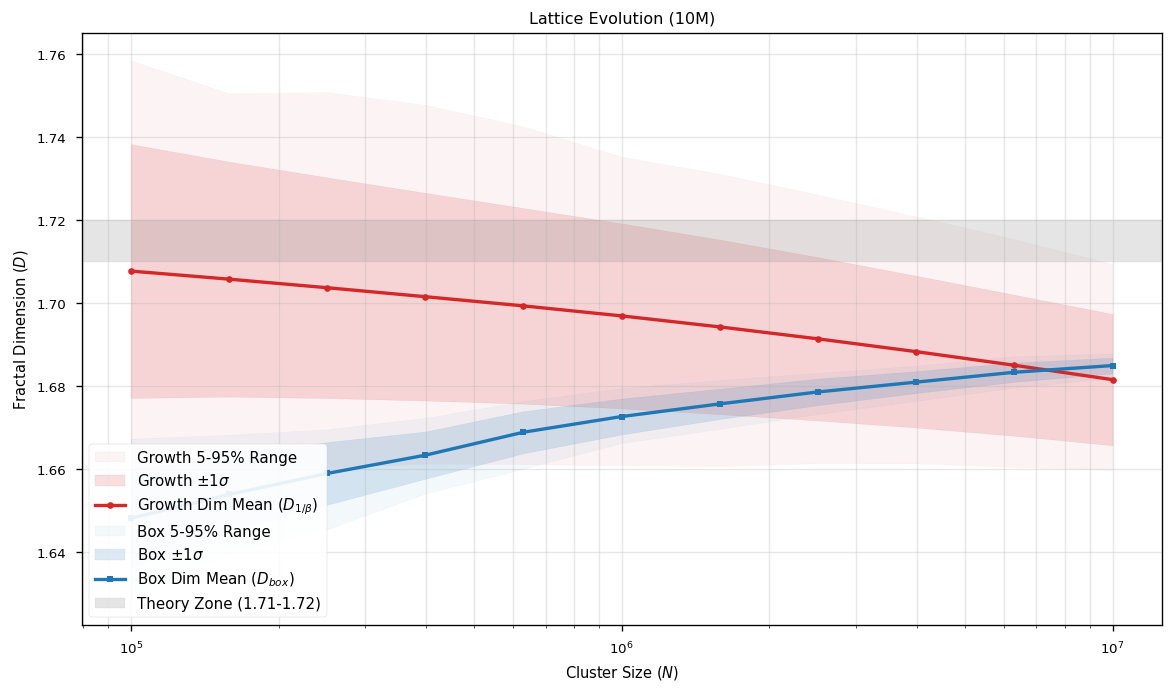

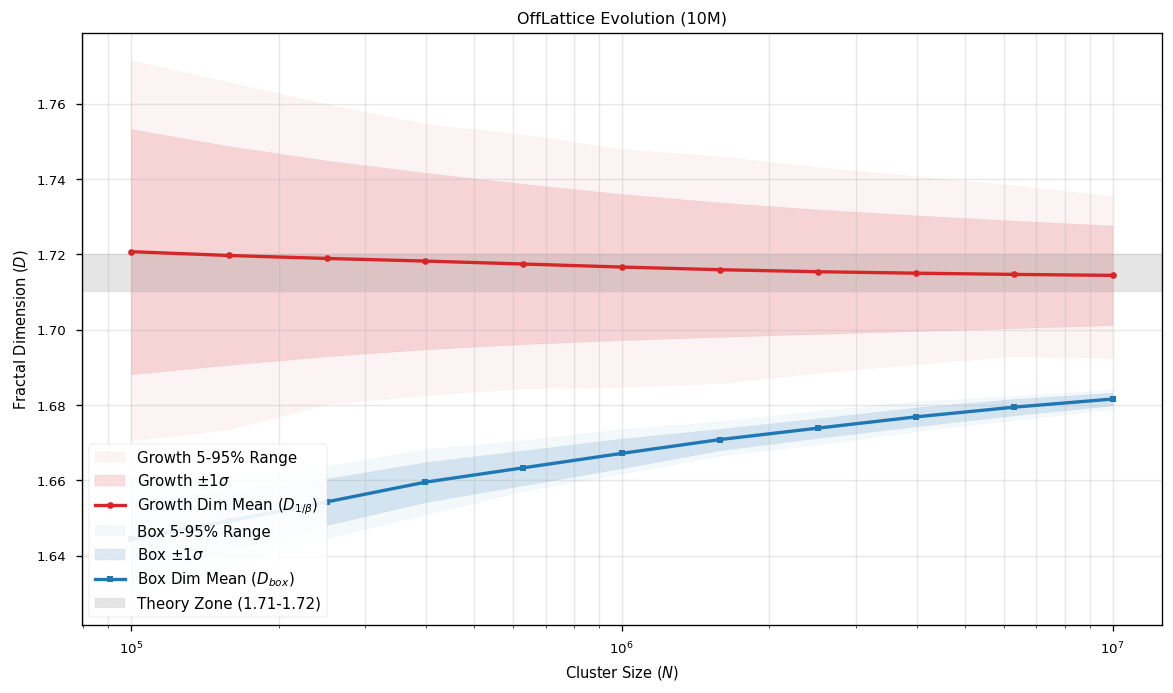

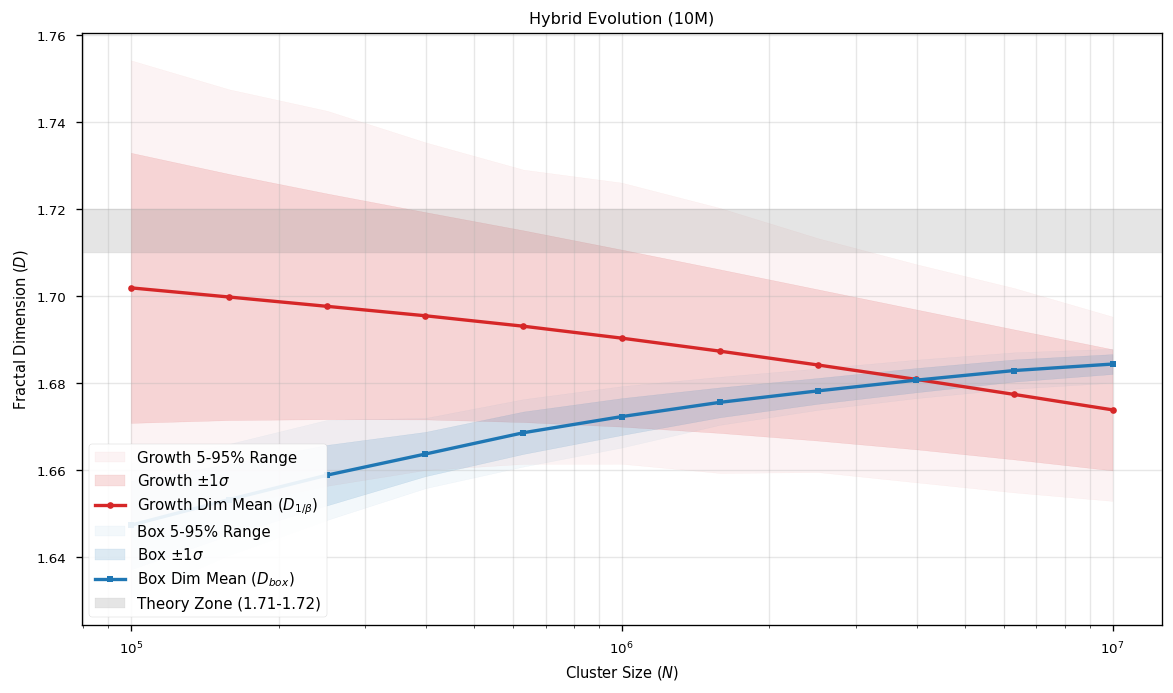

In [45]:
# Lattice
plot_batch_dimension_evolution(datasets, model_name="Lattice", size_label="10M")
#plot_batch_dimension_evolution(datasets, model_name="Lattice", size_label="1M")
# Off-Lattice
plot_batch_dimension_evolution(datasets, model_name="OffLattice", size_label="10M")

# Hybrid
plot_batch_dimension_evolution(datasets, model_name="Hybrid", size_label="10M")

formatting for diss (histograms)

Figure saved successfully to: ../latex/images/combined_dimension_histograms.pdf


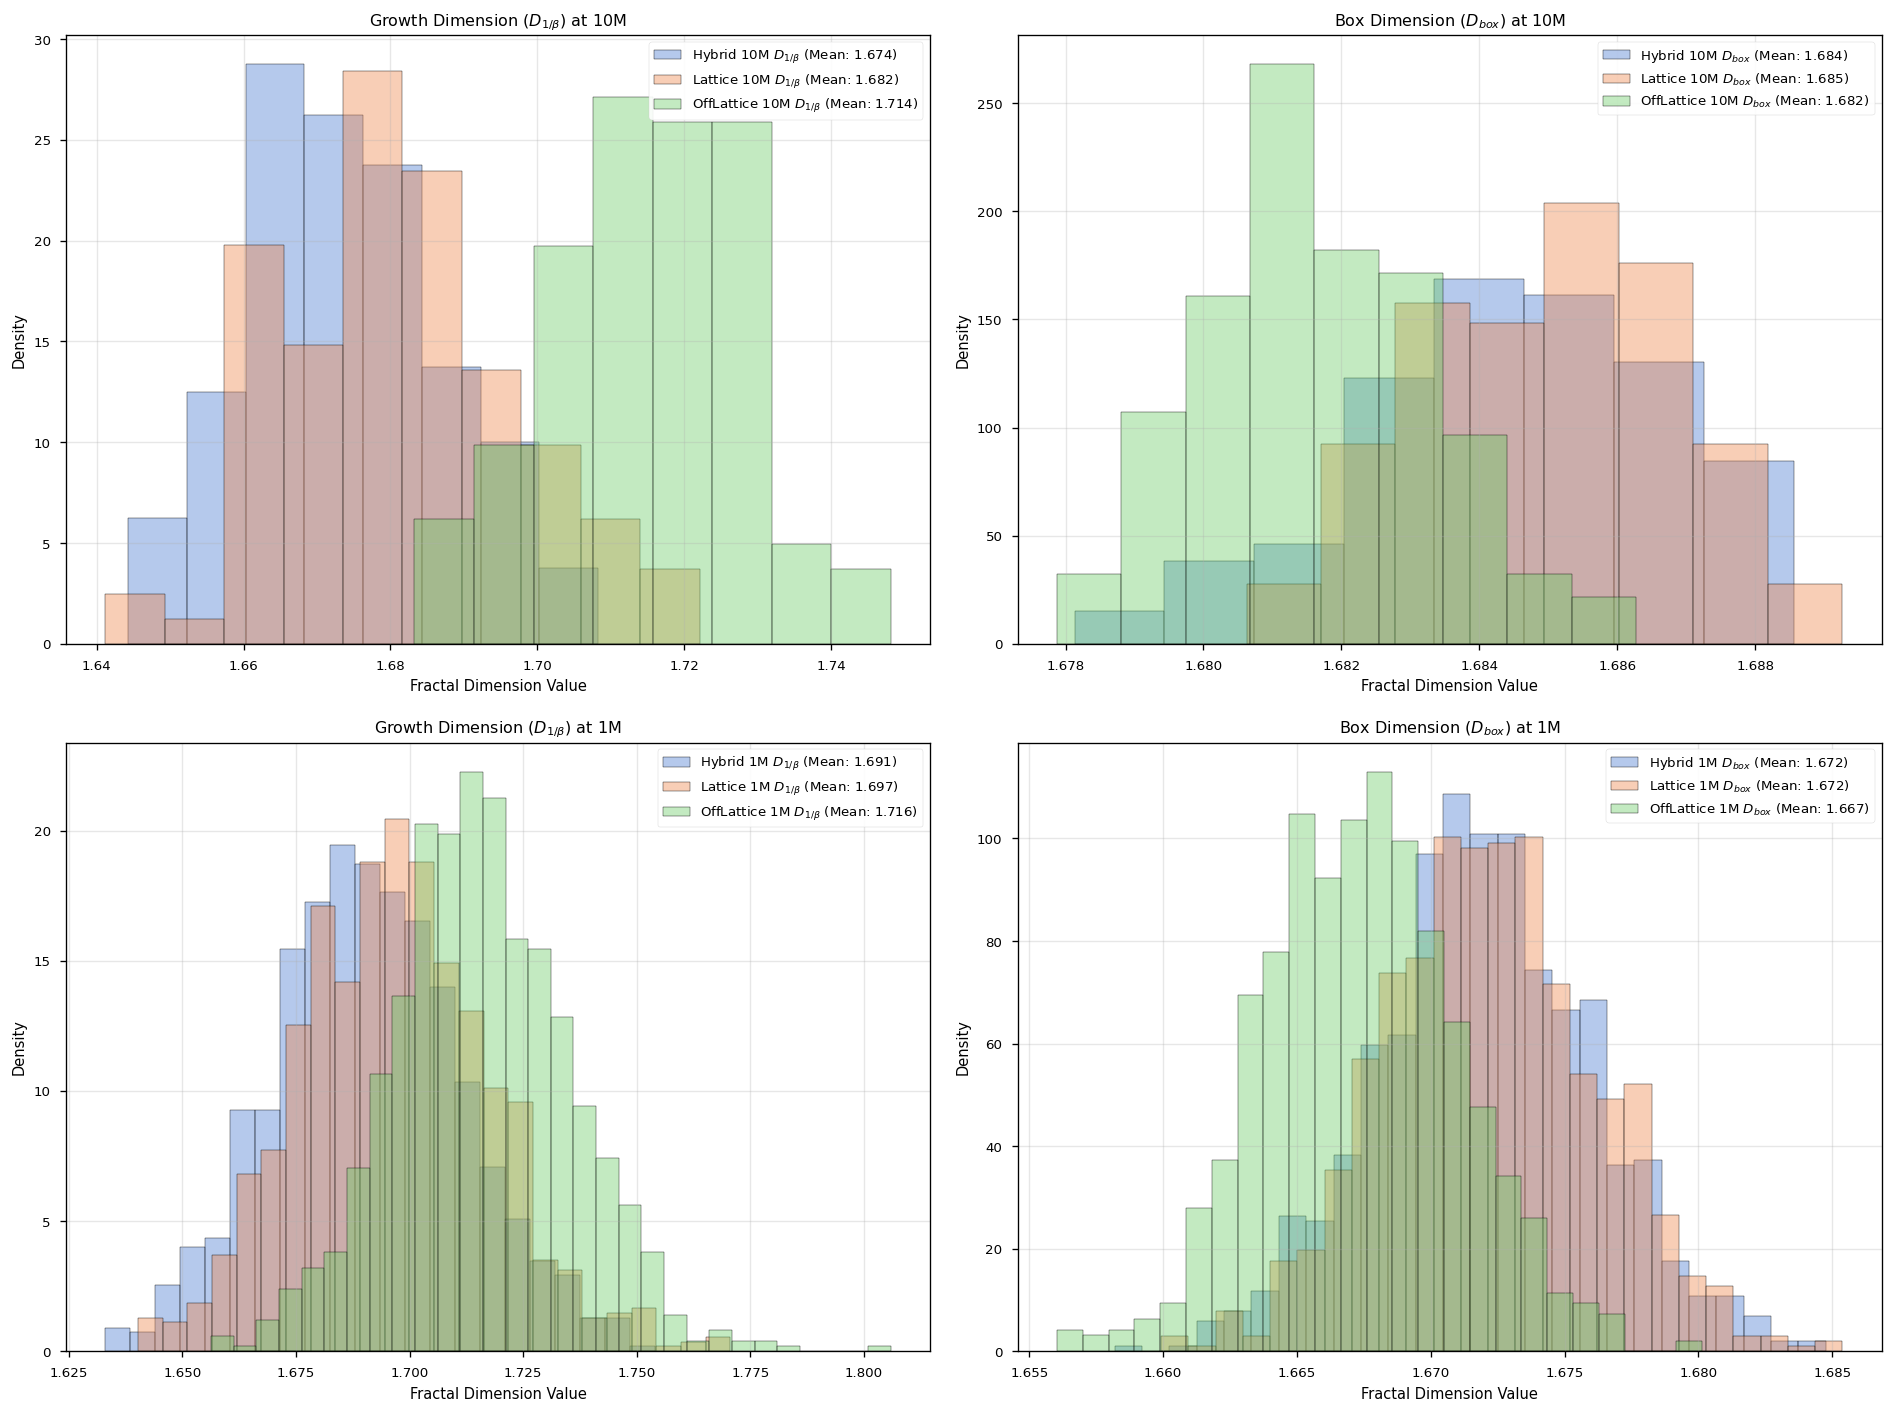

In [41]:
kde_on = False
plt.rcParams.update({'font.size': 14})

# 2. Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten() # Flattens the 2x2 matrix into a 1D list

# 3. Define specifications and plot directly to the axes
specs1 = [
    ('Hybrid', '10M', 'D_growth'),
    ('Lattice', '10M', 'D_growth'),
    ('OffLattice', '10M', 'D_growth')
]
plot_distributions(datasets, specs1, title="Growth Dimension ($D_{1/\\beta}$) at 10M", ax=axes[0], kde_on=kde_on)

specs2 = [
    ('Hybrid', '10M', 'D'),
    ('Lattice', '10M', 'D'),
    ('OffLattice', '10M', 'D')
]
plot_distributions(datasets, specs2, title="Box Dimension ($D_{box}$) at 10M", ax=axes[1], kde_on=kde_on)

specs3 = [
    ('Hybrid', '1M', 'D_growth'),
    ('Lattice', '1M', 'D_growth'),
    ('OffLattice', '1M', 'D_growth')
]
plot_distributions(datasets, specs3, title="Growth Dimension ($D_{1/\\beta}$) at 1M", ax=axes[2], kde_on=kde_on)

specs4 = [
    ('Hybrid', '1M', 'D'),
    ('Lattice', '1M', 'D'),
    ('OffLattice', '1M', 'D')
]
plot_distributions(datasets, specs4, title="Box Dimension ($D_{box}$) at 1M", ax=axes[3] , kde_on=kde_on)

# 4. Adjust layout so titles and labels don't overlap
plt.tight_layout()

# 5. Save the figure as a PDF for LaTeX
save_path = '../latex/images/combined_dimension_histograms.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, bbox_inches='tight')
print(f"Figure saved successfully to: {save_path}")

# Display in the notebook
plt.show()

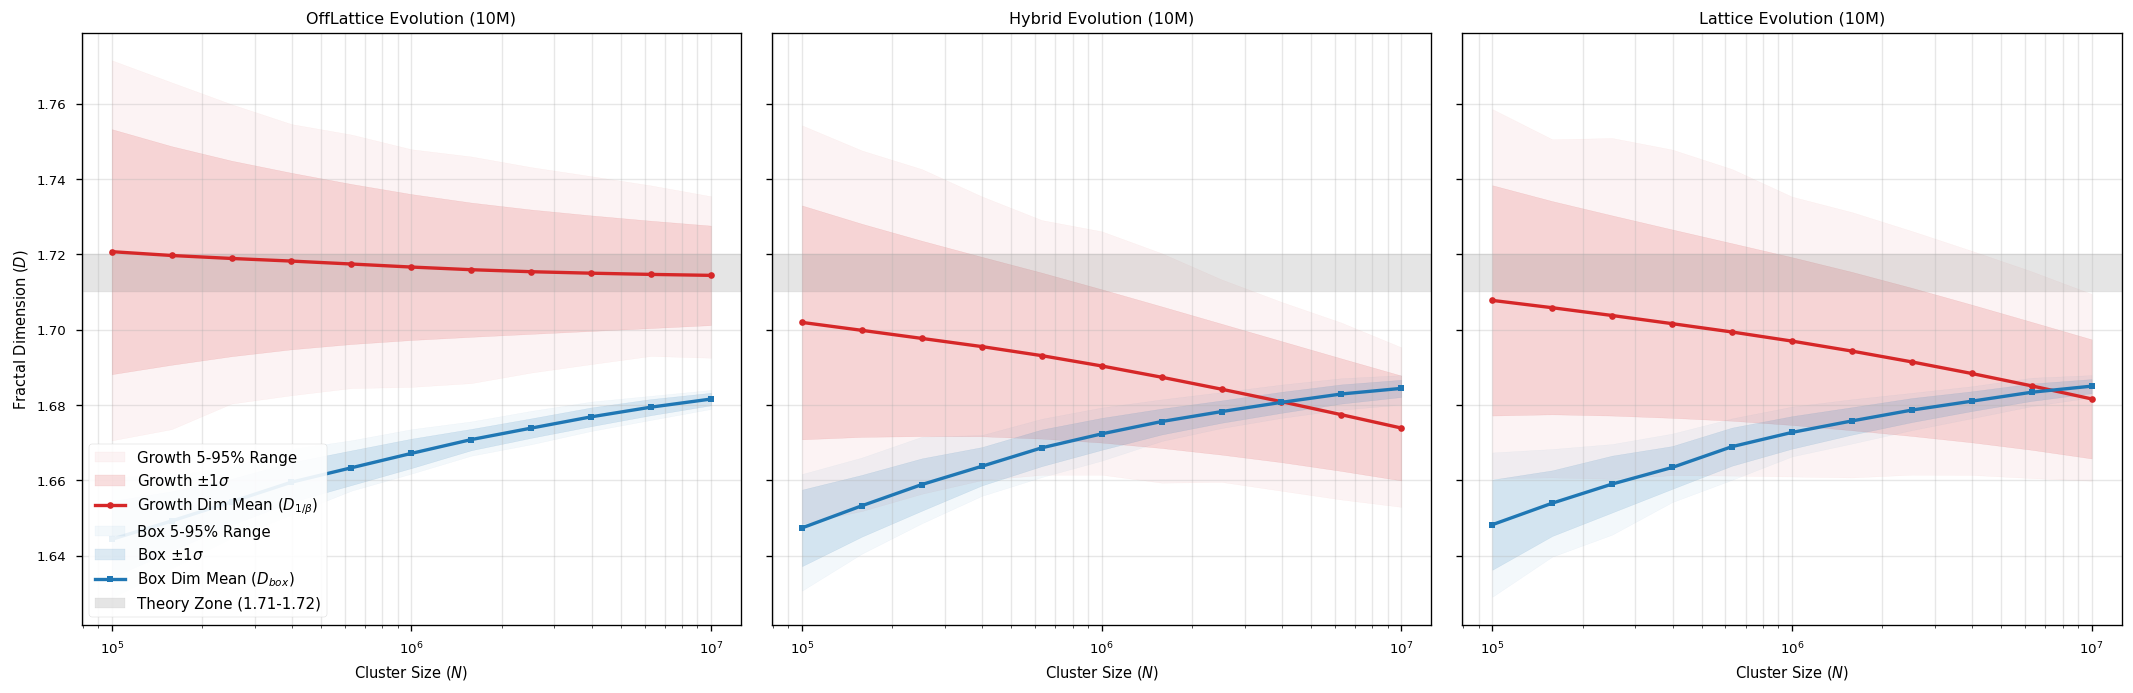

In [46]:
plt.rcParams.update({'font.size': 14})

# We use sharey=True so all three plots are perfectly scaled to each other!
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)

# Plot the 10M evolutions side-by-side
plot_batch_dimension_evolution(datasets, model_name="OffLattice", size_label="10M", ax=axes[0])
plot_batch_dimension_evolution(datasets, model_name="Hybrid", size_label="10M", ax=axes[1])
plot_batch_dimension_evolution(datasets, model_name="Lattice", size_label="10M", ax=axes[2])

plt.tight_layout()

# Save the figure as a PDF for LaTeX
"""save_path = '../latex/images/batch_dimension_evolution.pdf'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight')
print(f"Figure saved successfully to: {save_path}")
"""
plt.show()